In [1]:
from imports_IBM_NM import *
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib as mpl
mpl.rc('text', usetex = True)
mpl.rc('font', family = 'serif')
colors_blais = ['#33658A','#86BBD8']
colors_greg = ['#9A0EEA','#BF77F6','#030AA7','#0165FC','#39AD48','#F97306','#F7022A']

In [3]:
token = '2712985633675e074d63da9266dba7714d932b8e447f0f4632ca0965701237c6fb67854d65b3457cf7087e056cda6859748c77bd7721251cdaf17e9a1e30e6cc'
provider = qiskit_ibm_provider.IBMProvider(token)
instance = 'ibm-q-ornl/ornl/phy147'
device = 'guadalupe'
backend_name = get_backend_name(device)

In [4]:
# Define noise characterization protocols
qubit = 6
nc = noise_characterization(None, qubit, m_FTTPS=7, num_T1=10, num_T2=10)

In [5]:
nc.T2_dt = nc.I_duration
nc.T1_dt = nc.I_duration

In [6]:
def gen_T2DD_circs(n_pulses, flip=True):
    delays_t2 = np.around(np.linspace(nc.T2_dt, nc.T2_periods * nc.T2_time * 1e-6, nc.num_T2),8)
    
    circs = []

    for t2_idx,d in enumerate(delays_t2):
        num_Is = int(d/nc.I_duration/n_pulses/2) if n_pulses>0 else int(d/nc.I_duration)

        q = cirq.GridQubit(0,0)
        circ = cirq.Circuit()
        circ.append((cirq.X**.5).on(q))
        
        if n_pulses==0:
            circ.append([cirq.I.on(q)]*num_Is)
        else:
            for n in range(n_pulses):
                circ.append([cirq.I.on(q)]*num_Is)
                if n%2==1: circ.append([cirq.X.on(q)])
                if n%2==0: circ.append([cirq.Z.on(q),cirq.X.on(q),cirq.Z.on(q)] if flip else [cirq.X.on(q)])
                circ.append([cirq.I.on(q)]*num_Is)

        circ.append((cirq.X**(.5 if n_pulses%2==1 else -0.5)).on(q))
        circ.append(cirq.measure(q))
        circs.append(circ)
    return circs

In [7]:
circuit_batch = {}
circuits = {}

nc.num_T1 = 30
nc.T1_periods = 3
nc.T1_time = 50
T1_circs = nc.generate_T1_circuits()
circuits['t1'] = T1_circs
for k,circ in enumerate(T1_circs):
    circuit_batch['t1-%d'%k] = cirq2qiskit(circ)

T1 (time, num): (50 us, 30)


In [8]:
nc.num_T2 = 50
nc.T2_time = 50
nc.T2_periods = 1
print("n_pulses:", end=' ')
for n_pulses in [0,2,4,6]:
    print("[%d]"%n_pulses, end=' ')
    T2_circs = gen_T2DD_circs(n_pulses)
    for k,circ in enumerate(T2_circs):
        circuit_batch['t2dd%d-%d'%(n_pulses,k)] = cirq2qiskit(circ)
    circuits['t2dd%d'%n_pulses] = T2_circs

n_pulses: [0] [2] [4] [6] 

In [9]:
nc.flip = True
nc.measure_FTTPS = False
nc.FTTPS_circs = nc.generate_FTTPS_circuits()

for k,circ in enumerate(nc.FTTPS_circs):
    if k<70:
        circ.append(cirq.measure(cirq.GridQubit(0,0)))
        circuit_batch['fttps-%d'%k] = cirq2qiskit(circ)
    
circuits['fttps'] = nc.FTTPS_circs

FTTPS num: 128


In [10]:
exp_type = ['t1','t2dd0','t2dd2','t2dd4','t2dd6','fttps']
exp_lens = [nc.num_T1] + [nc.num_T2]*(len(exp_type)-2)+[nc.num_FTTPS]
exp_idxs = [0]+list(np.cumsum(exp_lens))

In [11]:
len(circuit_batch)

300

In [12]:
dt = nc.l_us
shots = 5000

# Collect Experiment

In [13]:
filename = 'guadalupe-1f_jobid-2023_07_15_120006'
print(filename)
job_id = 'cipc51jc2439q34ac3d0'
print(job_id)

guadalupe-1f_jobid-2023_07_15_120006
cipc51jc2439q34ac3d0


In [14]:
jobs = provider.backend.jobs(backend_name=backend_name)
job = provider.backend.retrieve_job(job_id)

# Data Collection

In [15]:
num_T1 = 30
num_T2 = 50
num_FTTPS = 2**7
exp_type = ['t1','t2dd0','t2dd2','t2dd4','t2dd6','fttps']
exp_lens = [num_T1] + [num_T2]*(len(exp_type)-2)+[num_FTTPS]
exp_idxs = [0]+list(np.cumsum(exp_lens))
shots = 5000

In [16]:
def get_id(idx):
    if idx<nc.num_T1:
        return 't1-%d'%(idx)
    elif nc.num_T1<=idx<nc.num_T2*6:
        n_pulse = (idx-nc.num_T1)//nc.num_T2
        return 't2dd%d-%d'%(n_pulse,idx-n_pulse*nc.num_T2)
    else:
        print("Index out of range.")

In [17]:
all_counts_dict = job.result().get_counts()

n_exps = len(all_counts_dict)
print("Total number of experiments:", n_exps)

Total number of experiments: 300


In [18]:
ps_1f = {}
for exp_num, exp in enumerate(exp_type):
    ps_1f[exp] = counts2ps(all_counts_dict[exp_idxs[exp_num]:exp_idxs[exp_num+1]], shots)

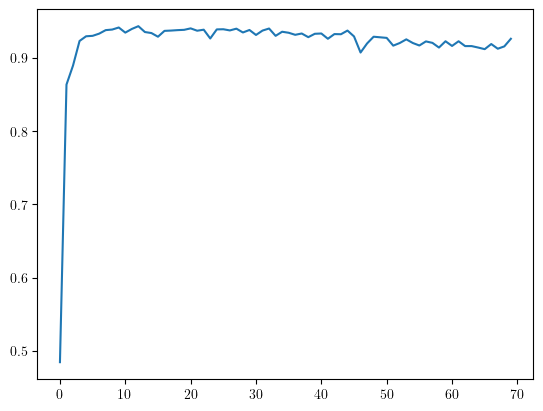

In [19]:
plt.plot(ps_1f['fttps'])
plt.show()

# Analysis

## T1

In [20]:
ps_t1 = ps_1f['t1']

x_vals = {}
x_vals['t1'] = np.array([len(circuit_batch['t1-%d'%i])*dt for i in range(nc.num_T1)])

In [21]:
spam = 1-ps_t1[0]
ps_t1_fun = lambda t,gamma,q : (q-spam)*np.exp(-t*gamma)+(1-q)
params, cov = spopt.curve_fit(ps_t1_fun, x_vals['t1'], ps_t1, p0=(1/nc.T1_time,1))

T1_fit = 1/params[0]
q = params[1]

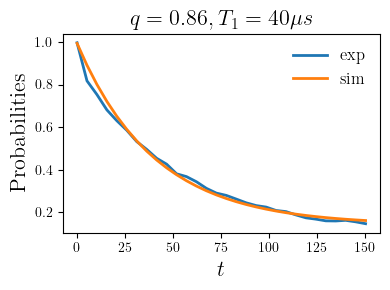

In [22]:
plt.figure(dpi=100, figsize=(4,3))
exp = 't1'
plt.title('$q=%.2f, T_1=%d \mu s$'%(q, T1_fit), size=16)

plt.plot(x_vals['t1'],ps_t1, label='exp',lw=2)
plt.plot(x_vals['t1'],ps_t1_fun(x_vals['t1'],*params),lw=2, label='sim')

plt.ylabel('Probabilities', fontsize=16)
plt.xlabel('$t$', fontsize=16)
plt.legend(frameon=False, fontsize=12)
plt.tight_layout()
plt.show()

# Simulation

In [23]:
import scipy

paulis = [pauli_x, pauli_y, pauli_z]
rho_0 = np.array([[1,0],[0,0]])
v0 = [np.trace(rho_0@pauli) for pauli in paulis]

def Gmat(theta, alpha, beta, eta, eps):
    return np.array([[-alpha, -beta, 0],
                     [beta, -alpha , -theta*(1+eps)],
                     [0,theta*(1+eps), -eta]])/dt

sv_backend = qk.providers.aer.StatevectorSimulator()

def sim_corr(circ, alpha=1e-10, beta=0, gamma=1e-10, eps=0, q=1, spam=0, p=0, S=NullSchWARMAFier(), num_MC=1, verbose=0):
    t_circ = qk.compiler.transpile(circ, backend=sv_backend, basis_gates=['id','x','rz','sx'], 
                                         initial_layout=[0], optimization_level=0)
    
#     len_circ = len(t_circ)
    str_circ = str(t_circ)
    len_circ = str_circ.count('X') + str_circ.count('I')
    noise_trajs = np.reshape(S.gen_noise_instances(cirq.Circuit([cirq.I.on(cirq.GridQubit(1,1))]*len_circ), num_MC=num_MC), (num_MC,len_circ) )
    
    # c vector
    c = np.array([0,0,gamma*(2*q-1)])/dt
    # Identity
    G_0 = Gmat(0, alpha, beta, gamma, eps)
    Ginv_0 = scipy.linalg.inv(G_0)
    eGt_0 = scipy.linalg.expm(G_0*dt)
    
    ps_all = []
    for j,noise_traj in enumerate(noise_trajs):
        i = 0
        vt = [np.real(v0)]
        for Cinst in t_circ:
            instruction = Cinst[0]
            name = instruction.name
            if name=='rz':
                new_vt = ns.bloch_update_rz(vt[-1], theta=float(instruction.params[0]))
                i-=1
            elif name=='x':
                G = Gmat(np.pi, alpha+p, beta, gamma+p, eps)
                Ginv = scipy.linalg.inv(G)
                eGt = scipy.linalg.expm(G*dt)
                new_vt = eGt@vt[-1] + (eGt-np.identity(3))@Ginv@c
                new_vt = ns.bloch_update_rz(new_vt, theta=noise_traj[i])
            elif name=='sx':
                G = Gmat(np.pi/2, alpha+p, beta, gamma+p, eps)
                Ginv = scipy.linalg.inv(G)
                eGt = scipy.linalg.expm(G*dt)
                new_vt = eGt@vt[-1] + (eGt-np.identity(3))@Ginv@c
                new_vt = ns.bloch_update_rz(new_vt, theta=noise_traj[i])
            elif name=='id':
                new_vt = eGt_0@vt[-1] + (eGt_0-np.identity(3))@Ginv_0@c
                new_vt = ns.bloch_update_rz(new_vt, theta=noise_traj[i])
            elif name=='barrier' or name=='measure':
                if verbose>0: print(name)
                continue
            else:
                print("unknown gate/instruction:", instruction)
                return 0
            i+=1
            vt.append( list(np.real(np.around(new_vt, 6)) ) )

        rho_t = (Id + vt[-1][0]*pauli_x + vt[-1][1]*pauli_y + vt[-1][2]*pauli_z)/2
        if spam: rho_t = (1-spam)*rho_t + spam*pauli_x@rho_t@pauli_x 
        ps_all += [np.real(np.trace(rho_t @ rho_0))]
    return ps_all

In [24]:
ns = noisy_simulation(None, 0)

In [25]:
gamma = 1-np.exp(-dt/T1_fit)
alpha = gamma/2

# Higher Order DD

In [26]:
circuit_batch = {}
circuits = {}

nc.num_T1 = 25
nc.T1_periods = 3
T1_circs = nc.generate_T1_circuits()
circuits['t1'] = T1_circs
for k,circ in enumerate(T1_circs):
    circuit_batch['t1-%d'%k] = cirq2qiskit(circ)

T1 (time, num): (50 us, 25)


In [27]:
nc.num_T2 = 25
nc.T2_time = 50
nc.T2_periods = 1
print("n_pulses:", end=' ')
n_pulses_list = np.arange( (300-nc.num_T1)/nc.num_T2, dtype=int )*2
print(n_pulses_list)
for n_pulses in n_pulses_list:
    print("[%d]"%n_pulses, end=' ')
    T2_circs = gen_T2DD_circs(n_pulses)
    for k,circ in enumerate(T2_circs):
        circuit_batch['t2dd%d-%d'%(n_pulses,k)] = cirq2qiskit(circ)
    circuits['t2dd%d'%n_pulses] = T2_circs

n_pulses: [ 0  2  4  6  8 10 12 14 16 18 20]
[0] [2] [4] [6] [8] [10] [12] [14] [16] [18] [20] 

In [68]:
def get_circ_len(circ):
    length = 0
    for moment in circ:
        gate = moment.operations[0].gate
        if gate in [cirq.X**-0.5,cirq.X**0.5,cirq.X,cirq.I]:
            length += 1
    return length

In [74]:
tt = np.array([dt*get_circ_len(circ) for circ in T2_circs])

In [97]:
exp_type = ['t1']+['t2dd%d'%d for d in n_pulses_list]#+['fttps']
print(exp_type)
exp_lens = [nc.num_T1] + [nc.num_T2]*(len(exp_type)-2)#+[nc.num_FTTPS]
exp_idxs = [0]+list(np.cumsum(exp_lens))

['t1', 't2dd0', 't2dd2', 't2dd4', 't2dd6', 't2dd8', 't2dd10', 't2dd12', 't2dd14', 't2dd16', 't2dd18', 't2dd20']


In [98]:
dt = nc.l_us
shots = 5000

In [238]:
filename = 'guadalupe-1f_hidd_jobid-2023_07_19_082209'
print(filename)
job_id = 'cirtascb0ilk0bcp6jng'
print(job_id)

guadalupe-1f_hidd_jobid-2023_07_19_082209
cirtascb0ilk0bcp6jng


In [239]:
jobs = provider.backend.jobs(backend_name=backend_name)
job = provider.backend.retrieve_job(job_id)

In [240]:
all_counts_dict = job.result().get_counts()

n_exps = len(all_counts_dict)
print("Total number of experiments:", n_exps)

Total number of experiments: 300


In [241]:
ps_dd = {exp:counts2ps(all_counts_dict[25*exp_num:25*(exp_num+1)], shots) for exp_num, exp in enumerate(exp_type)}
x_vals = {exp:np.linspace(0,nc.T2_time*nc.T2_periods,len(ps_dd['t2dd0'])) for exp in exp_type}

spam = np.mean([1-ps_dd[exp][0] for exp in exp_type])
fit = lambda t,b: (1+(1-2*spam)*np.exp(-b*t))/2

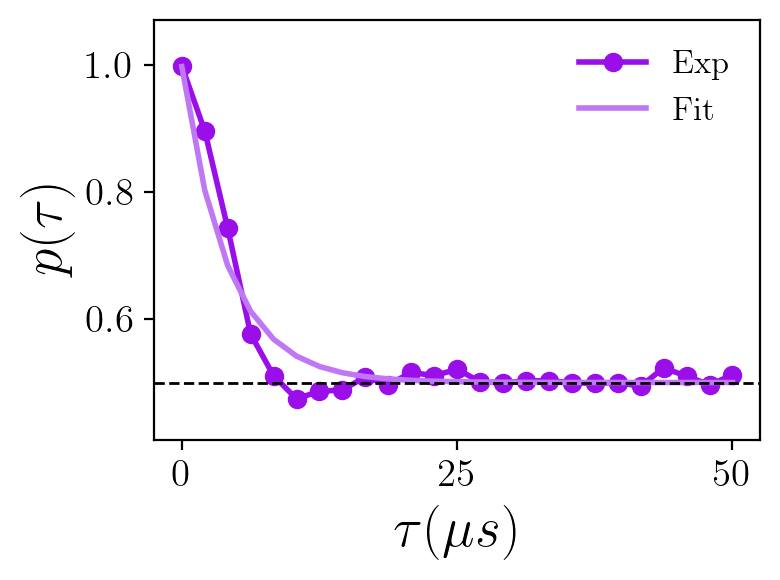

In [243]:
plt.figure(figsize=(4,3), dpi=200)

exp_num = 0
exp = 't2dd0'
plt.plot(x_vals[exp], ps_dd[exp], color=colors_greg[exp_num], lw=2, marker='o', alpha=1, label='Exp')
    
params, _ = spopt.curve_fit(fit, x_vals[exp], ps_dd[exp], p0=(0))
plt.plot(x_vals[exp], fit(x_vals[exp], *params), color=colors_greg[1], lw=2,alpha=1, label='Fit')    
    
plt.ylabel(r'$p(\tau)$', fontsize=20)
plt.xlabel(r'$\tau (\mu s)$', fontsize=20)
plt.ylim(0.41,1.07)
plt.xticks([0,25,50], size=14)
plt.yticks([0.6,0.8,1.], size=14)

plt.axhline(0.5, color='k', ls='--', lw=1)
plt.legend(frameon=False, bbox_to_anchor=(1,1), fontsize=12, title_fontsize=16, ncol=1)
plt.tight_layout()
plt.show()

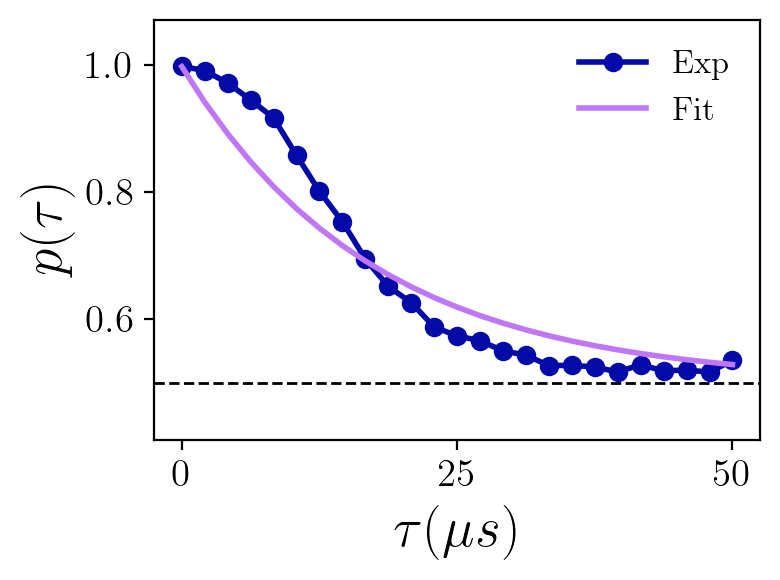

In [242]:
plt.figure(figsize=(4,3), dpi=200)

exp_num = 2
exp = 't2dd2'
plt.plot(x_vals[exp], ps_dd[exp], color=colors_greg[exp_num], lw=2, marker='o', alpha=1, label='Exp')
    
params, _ = spopt.curve_fit(fit, x_vals[exp], ps_dd[exp], p0=(0))
plt.plot(x_vals[exp], fit(x_vals[exp], *params), color=colors_greg[1], lw=2,alpha=1, label='Fit')    
    
plt.ylabel(r'$p(\tau)$', fontsize=20)
plt.xlabel(r'$\tau (\mu s)$', fontsize=20)
plt.ylim(0.41,1.07)
plt.xticks([0,25,50], size=14)
plt.yticks([0.6,0.8,1.], size=14)

plt.axhline(0.5, color='k', ls='--', lw=1)
plt.legend(frameon=False, bbox_to_anchor=(1,1), fontsize=12, title_fontsize=16, ncol=1)
plt.tight_layout()
plt.show()

In [35]:
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap_greg', colors_greg, N=len(exp_type)-3)
colors_fine = [cmap(i) for i in range(cmap.N)]

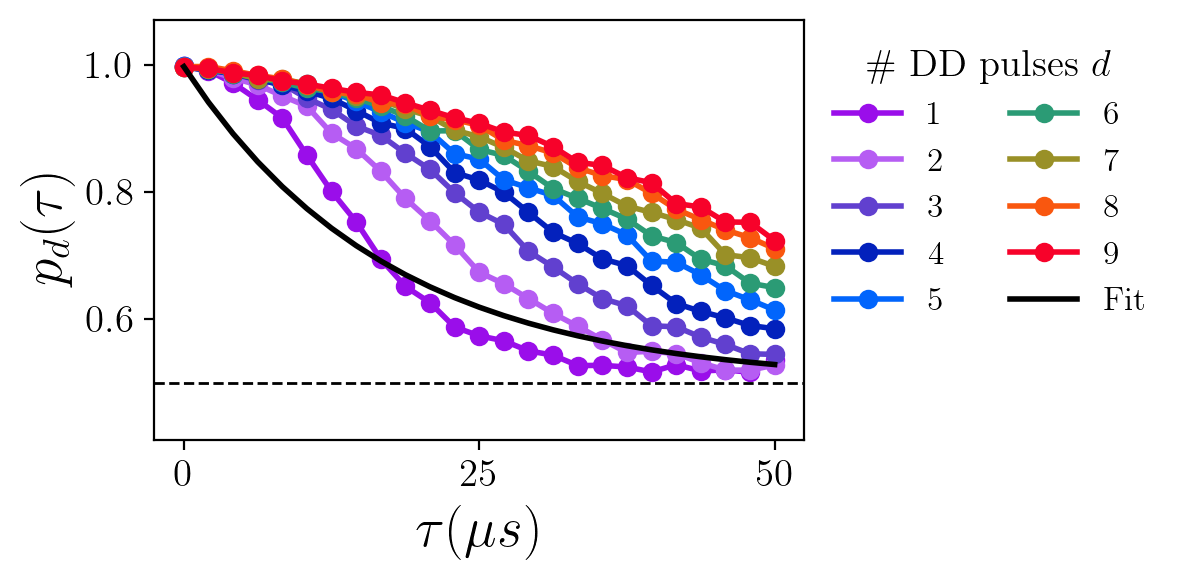

In [36]:
plt.figure(figsize=(6,3), dpi=200)

for exp_num, exp in enumerate(exp_type[2:-1]):
    plt.plot(x_vals[exp], ps_dd[exp], color=colors_fine[exp_num], lw=2, marker='o', alpha=1, label=(exp_num+1))
    
params, _ = spopt.curve_fit(fit, x_vals['t2dd2'], ps_dd['t2dd2'], p0=(0))
plt.plot(x_vals['t2dd2'], fit(x_vals['t2dd2'], *params), color='k', lw=2,alpha=1, label='Fit')    
    
plt.ylabel(r'$p_d(\tau)$', fontsize=20)
plt.xlabel(r'$\tau (\mu s)$', fontsize=20)
plt.ylim(0.41,1.07)
plt.xticks([0,25,50], size=14)
plt.yticks([0.6,0.8,1.], size=14)

plt.axhline(0.5, color='k', ls='--', lw=1)
plt.legend(frameon=False, title='\# DD pulses $d$', fontsize=12, title_fontsize=14, ncol=2, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

## Extract T2

<font size="4">
$$p(t) = \frac{1+e^{-\gamma t}e^{-\chi_0 t^2}\cos(\beta t)}{2}$$

dd = 0, λ = 0.0088, χ(τ) = 0.0028
dd = 1, λ = 0.0000, χ(τ) = 0.0015
dd = 2, λ = 0.0000, χ(τ) = 0.0010
dd = 3, λ = 0.0000, χ(τ) = 0.0007
dd = 4, λ = 0.0005, χ(τ) = 0.0006
dd = 5, λ = 0.0021, χ(τ) = 0.0005
dd = 6, λ = 0.0030, χ(τ) = 0.0004
dd = 7, λ = 0.0039, χ(τ) = 0.0003
dd = 8, λ = 0.0035, χ(τ) = 0.0003


C:\Users\14432\Anaconda3\envs\mezze_env\lib\site-packages\scipy\optimize\minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


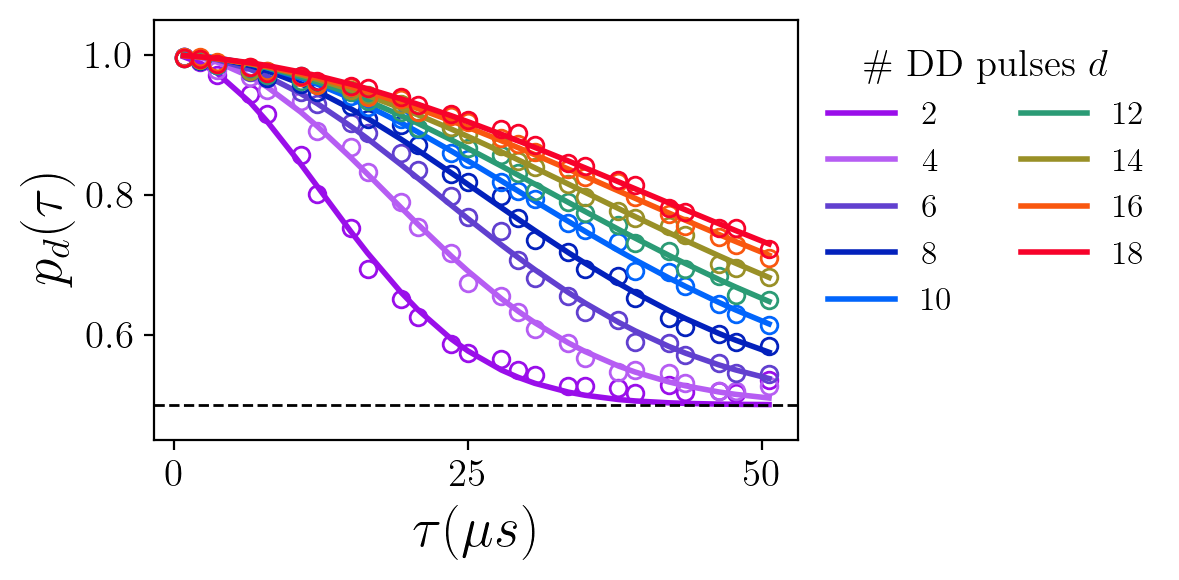

In [75]:
plt.figure(figsize=(6,3), dpi=200)

lmbdas = []
chis = []

p_t = lambda t,lmbda,chi: 0.5+0.5*np.exp(-np.abs(lmbda)*t/tt[-1]-chi*(t/tt[-1])**2)
for exp_num, exp in enumerate(exp_type[2:-1]):
    params, _ = spopt.curve_fit(p_t, tt, ps_dd[exp])
    lmbdas += [np.abs(params[0]*2/tt[-1])]
    chis += [params[1]/tt[-1]**2]
    print("dd = %d, λ = %.4f, χ(τ) = %.4f" % (exp_num, lmbdas[-1], chis[-1]))

    plt.plot(tt, ps_dd[exp], color=colors_fine[exp_num], lw=0, marker='o', mfc='None', alpha=1)
    plt.plot(tt, p_t(tt,*params), color=colors_fine[exp_num], lw=2, label=2*(exp_num+1))
    
plt.ylabel(r'$p_d(\tau)$', fontsize=20)
plt.xlabel(r'$\tau (\mu s)$', fontsize=20)
plt.ylim(0.45,1.05)
plt.xticks([0,25,50], size=14)
plt.yticks([0.6,0.8,1.], size=14)

plt.axhline(0.5, color='k', ls='--', lw=1)
plt.legend(frameon=False, title='\# DD pulses $d$', fontsize=12, title_fontsize=14, ncol=2, bbox_to_anchor=(1,1))
plt.tight_layout()
plt.show()

In [76]:
xx = np.concatenate([v for k,v in x_vals.items()][2:])

In [77]:
x_select = []
for k in range(10):
    x_k = []
    for i in range(10):
        x_k += [i==k]*25
    x_select += [x_k]

In [78]:
ps_combined =  np.concatenate([v for _,v in ps_dd.items()][2:])

In [79]:
def psws_T2(xx, T2,chi2,chi4,chi6,chi8,chi10,chi12,chi14,chi16,chi18,chi20):
    return np.piecewise(xx, x_select, 
              [lambda t: 0.5+0.5*np.exp(-t/T2-chi2*(t/tt[-1])**2),
              lambda t: 0.5+0.5*np.exp(-t/T2-chi4*(t/tt[-1])**2),
              lambda t: 0.5+0.5*np.exp(-t/T2-chi6*(t/tt[-1])**2),
              lambda t: 0.5+0.5*np.exp(-t/T2-chi8*(t/tt[-1])**2),
              lambda t: 0.5+0.5*np.exp(-t/T2-chi10*(t/tt[-1])**2),
              lambda t: 0.5+0.5*np.exp(-t/T2-chi12*(t/tt[-1])**2),
              lambda t: 0.5+0.5*np.exp(-t/T2-chi14*(t/tt[-1])**2),
              lambda t: 0.5+0.5*np.exp(-t/T2-chi16*(t/tt[-1])**2),
              lambda t: 0.5+0.5*np.exp(-t/T2-chi18*(t/tt[-1])**2),
              lambda t: 0.5+0.5*np.exp(-t/T2-chi20*(t/tt[-1])**2)])

In [80]:
params, cov = spopt.curve_fit(psws_T2, xx, ps_combined, p0=(30,*([0.]*10)))
T2 = params[0]
dT2 = cov[0,0]**0.5
dchis = [cov[i,i]**0.5/tt[-1] for i in range(1,11)]

print("T2    = %.d  +/- %d us"%(T2,dT2))
for k,chi in enumerate(params[1:]):
    print("chi_%d = %.4f +/- %.4f"%(2*k+2,chi/tt[-1]**2, dchis[k]))

T2    = 842  +/- 154 us
chi_2 = 0.0031 +/- 0.0026
chi_4 = 0.0015 +/- 0.0011
chi_6 = 0.0010 +/- 0.0007
chi_8 = 0.0007 +/- 0.0006
chi_10 = 0.0005 +/- 0.0005
chi_12 = 0.0005 +/- 0.0004
chi_14 = 0.0004 +/- 0.0004
chi_16 = 0.0003 +/- 0.0004
chi_18 = 0.0003 +/- 0.0004
chi_20 = 0.0003 +/- 0.0004


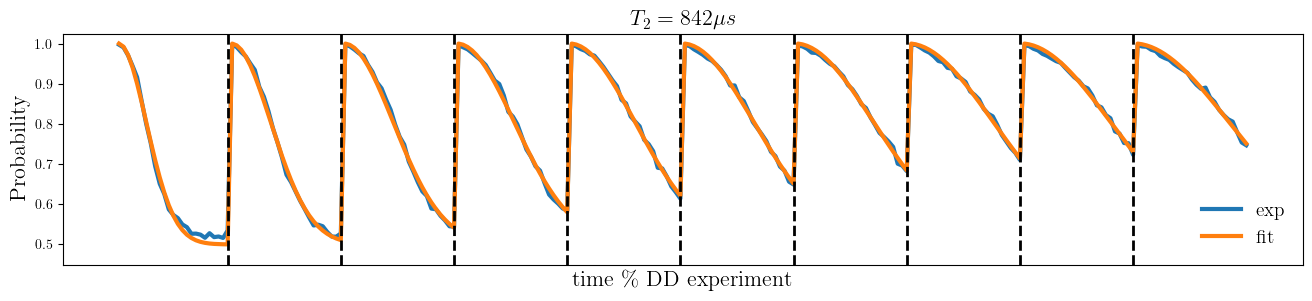

In [81]:
ps_fit = psws_T2(xx, *params)

plt.figure(figsize=(16,3), dpi=100)
plt.title('$T_2 = %d \mu s$' % T2, size=16)
plt.plot(ps_combined, lw=3, label='exp')
plt.plot(ps_fit, lw=3, label='fit')
plt.ylim(bottom=0.45)
# plt.xticks(np.arange(0,len(ps_fit),50),np.around(xx[::50],3))
plt.xticks([])
plt.ylabel('Probability', size=16)
plt.xlabel('time \% DD experiment', size=16)
plt.legend(frameon=False, fontsize=14)
for i in range(9):
    plt.axvline((i+1)*25-1, color='k', lw=2, ls='--')
plt.show()

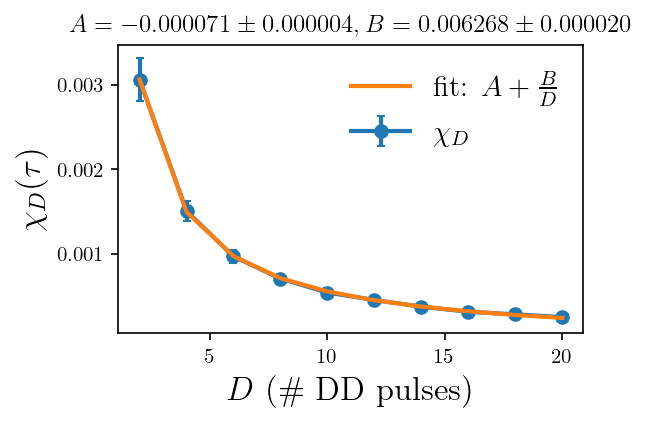

In [82]:
dd = 2*(np.arange(10)+1)
fun_exp = lambda d,a,b: a+b/d
chis = params[1:]/tt[-1]**2
params_chi, cov_chi = spopt.curve_fit(fun_exp, dd, chis)
dA = cov_chi[0,0]**0.5
dB = cov_chi[1,1]**0.5

plt.figure(figsize=(4,2.5), dpi=150)
plt.title("$A = %.6f\pm%.6f, B = %.6f\pm%.6f$"% (params_chi[0],dA,params_chi[1],dB))
plt.errorbar(dd, chis, np.array(dchis)/10, lw=2, marker='o', capsize=2, label='$\chi_D$')
plt.plot(dd, fun_exp(dd,*params_chi), lw=2, zorder=10, label=r'fit: $A + \frac{B}{D}$')
# plt.plot(dd, 3/(2*dd*1e3), lw=2, label=r'$\frac{1}{40 D}$')
plt.ylabel(r'$\chi_D(\tau)$', size=16)
plt.xlabel('$D$ (\# DD pulses)', size=16)
plt.legend(frameon=False, fontsize=14)
plt.show()

# Fitting FTTPS and T2+DD

In [83]:
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap_greg', colors_greg, N=len(exp_type)-2)
colors_fine = [cmap(i) for i in range(cmap.N)]

### Subtract AD decay

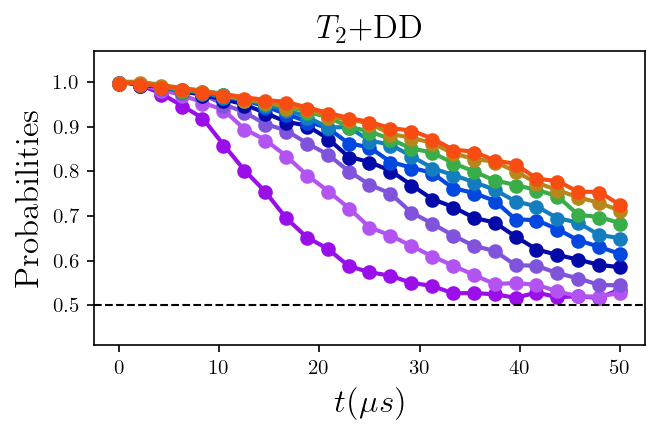

In [84]:
gamma = 1e-10

plt.figure(figsize=(4.5,3), dpi=150)
plt.title('$T_2$+DD', size=16)
ps_corrs = {}
beta = 0.001/dt
for exp_num, exp in enumerate(exp_type[2:-1]):
    tt = x_vals[exp]
    ps_raw = ps_dd[exp]
    plt.plot(tt, ps_raw, color=colors_fine[exp_num], lw=0, marker='o', alpha=1)
    ps_corrected = (1+(2*ps_raw-1)*np.exp(gamma/dt*tt/2)/(1-2*spam))/2
    plt.plot(tt, ps_corrected, color=colors_fine[exp_num], lw=2)
    ps_corrs[exp] = ps_corrected
    
plt.ylabel('Probabilities', fontsize=16)
plt.xlabel('$t (\mu s)$', fontsize=16)
plt.ylim(0.41,1.07)
plt.axhline(0.5, color='k', ls='--', lw=1)
plt.tight_layout()
plt.show()

In [85]:
p_t = lambda t,b,c,d: 0.5+0.5*np.exp(-b*t-c*t**2/1000)*np.cos(d*t)

# PSD fit

In [86]:
N = nc.num_FTTPS*2
worN = 8192
Phi, PhiRecon, num_gates = get_FTTS_FFs(N,worN=worN)
Phi = Phi.astype(np.float32)
num_gates = num_gates.astype(np.float32)

In [87]:
circs = []
nc.num_T2 = 25
list_pulses = [2,4,6]
for n_pulses in list_pulses:
    circs += gen_T2DD_circs(n_pulses,flip=False)

num_gates_t2 = np.concatenate([[2*(exp_num+1)]*nc.num_T2 for exp_num, exp in enumerate(exp_type[2:2+len(list_pulses)])])
num_gates_t2 = np.reshape(num_gates_t2,(len(list_pulses)*nc.num_T2,1))

Phi_t2 = np.array([np.abs(compute_gen_dephasing_Fourier(circ, worN=worN))**2/worN/2 for circ in circs])
Phi_t2_zy = Phi_t2[:,:,1,2]

In [89]:
ps_fttps = counts2ps(all_counts_dict[-nc.num_FTTPS:], shots)

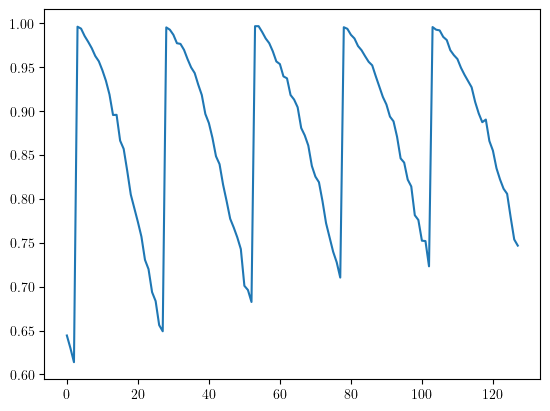

In [91]:
plt.plot(ps_fttps)
plt.show()

In [88]:
# FTTPS + T2DD
first = 1
last = len(ps_fttps)
Phi_4fit = np.concatenate((Phi[first:last],Phi_t2_zy))

num_gates_4fit = np.concatenate((num_gates[first:last],num_gates_t2))

ps_4fit = ps_fttps[first:]
for exp in exp_type[2:2+len(list_pulses)]:
    ps_4fit = np.concatenate((ps_4fit,ps_corrs[exp]))

NameError: name 'ps_fttps' is not defined

In [202]:
# FTTPS only
first = 1
last = len(ps_fttps)

Phi_4fit = Phi[first:last]
num_gates_4fit = num_gates[first:last]
ps_4fit = ps_fttps[first:]

NameError: name 'ps_fttps' is not defined

In [109]:
# T2DD only
Phi_4fit = Phi_t2_zy
num_gates_4fit = num_gates_t2
ps_4fit = np.concatenate([ps_corrs[exp] for exp in exp_type[2:2+len(list_pulses)]])

### Optimizing over ARMA size

In [110]:
print("a  b  q   AIC")
fit_qs = []
for a_len in range(1,6):
    for b_len in range(1,6):
        learner = ZDephasingFFLearner(b_len,a_len)
        fit_q = learner.fit(ps_4fit, Phi_4fit, num_gates_4fit)
        AIC = learner.akaike_info_criterion(ps_4fit, Phi_4fit, num_gates_4fit)
        print("%d %d %.7f %.2f" %(a_len, b_len, fit_q, AIC))
        fit_qs += [(a_len, b_len, fit_q, AIC)]

a  b  q   AIC


KeyboardInterrupt: 

In [436]:
q_opt = 1
for fit in fit_qs:
    if q_opt > fit[2]: 
        a_opt, b_opt, q_opt, AIC_opt = fit
print("Optimal values based on tf.model.eval:")
print("%d %d %.6f %.2f" %(a_opt, b_opt, q_opt, AIC_opt))

AIC_opt = 0
for fit in fit_qs:
    if AIC_opt > fit[3]: 
        a_opt, b_opt, q_opt, AIC_opt = fit
print("Optimal values based on AIC:")
print("%d %d %.6f %.2f" %(a_opt, b_opt, q_opt, AIC_opt))

Optimal values based on tf.model.eval:
5 5 0.000125 -330.10
Optimal values based on AIC:
4 2 0.000132 -334.41


In [437]:
# a_opt, b_opt = 4,5

In [438]:
qs = []
AICs = []
xs = []
for fit in fit_qs:
    qs += [fit[2]]
    AICs += [fit[3]]
    xs += ['(%d,%d)'%(fit[0],fit[1])]

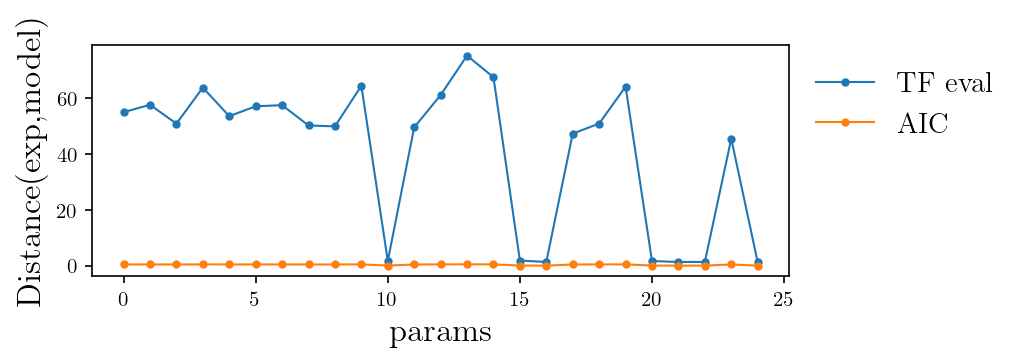

In [439]:
plt.figure(figsize=(6,2), dpi=150)
plt.plot(np.array(qs)*1e4, label='TF eval', marker='.', lw=1)
plt.plot((np.array(AICs) - min(AICs))*1.5e-3, label='AIC', marker='.', lw=1)
plt.ylabel('Distance(exp,model)', size=16)
plt.xlabel('params', size=16)
# plt.ylim(top=7.5)
plt.legend(frameon=False, fontsize=14, bbox_to_anchor=(1,1))
plt.show()

### Fit

In [111]:
a_opt, b_opt = 3,1
learner = ZDephasingFFLearner(b_opt,a_opt)
learner.fit(ps_4fit, Phi_4fit, num_gates_4fit)

0.00012483933824114501

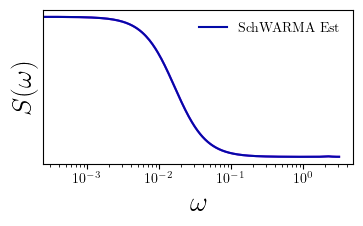

In [117]:
b_hat, a_hat = learner.convert_to_lfilter_form()
w, h_hat = si.freqz(b_hat,a_hat,worN = 2048*8, whole=False)
S = SimpleDephasingSchWARMAFier(b_hat,a_hat)

plt.figure(figsize=(4,2))

ww, PSD = S.psd(worN=worN)
plt.plot(ww,PSD, color=colors_greg[0])

ww, h_hat = si.freqz(b_hat,a_hat,worN=worN,whole=False)
PSD = np.abs(h_hat)**2
plt.plot(ww, np.abs(h_hat)**2,label='SchWARMA Est', color=colors_greg[2])

plt.ylabel(r'$S(\omega)$', fontsize=20)
plt.xlabel(r'$\omega$', fontsize=20)
plt.yticks([])
plt.xticks([])
plt.legend(frameon=False)
# plt.yscale('log')
plt.xscale('log')
plt.show()

# Analytical expression T2+DD

In [228]:
circs_pulses = {}
list_pulses = [2,4,6]
nc.num_T2 = 25
for n_pulses in list_pulses:
    circs_pulses[n_pulses] = gen_T2DD_circs(n_pulses,flip=False)

In [229]:
FFs_pulses = {pulses:{t:(np.abs(compute_gen_dephasing_Fourier(circ, worN=2*worN+1))**2/(2*worN)/2)[:worN,1,2]
                                for t,circ in enumerate(circs)} for pulses,circs in circs_pulses.items()}

In [230]:
ww, h_hat = si.freqz(b_hat,a_hat,worN=worN,whole=False)
PSD = np.abs(h_hat)**2

p_k = {}
for pulses,FFs in FFs_pulses.items():
    p_k[pulses] = []
    for t,FF in FFs.items():
        chi = np.sum(FF*PSD)*2
        p_k[pulses] += [(1+np.exp(-chi))/2]

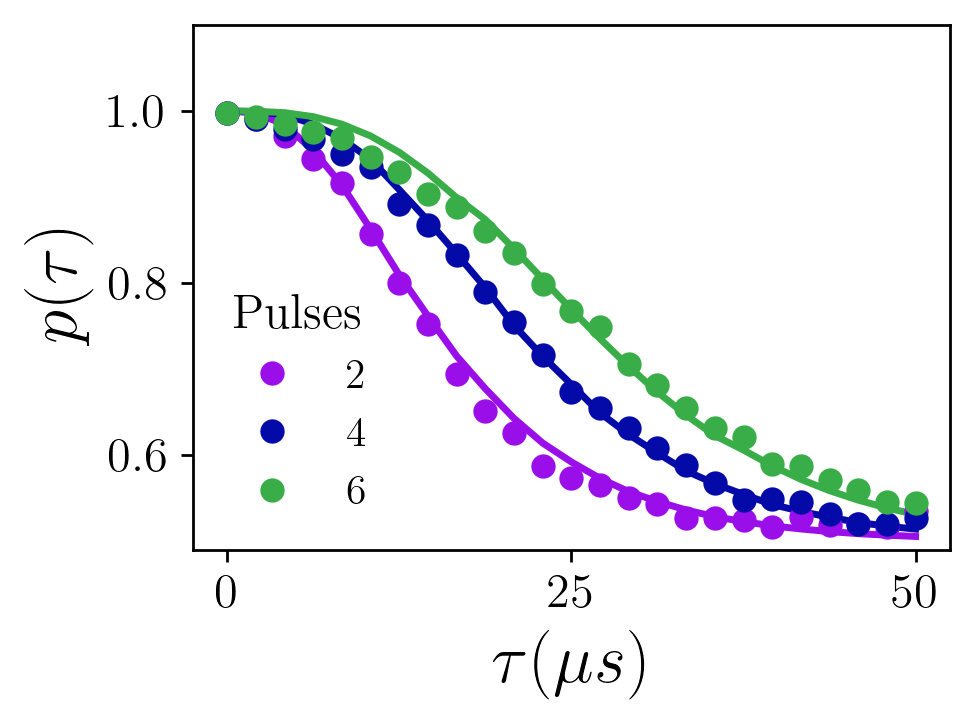

In [231]:
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap_greg', colors_greg, N=len(exp_type))
colors_fine = [cmap(i) for i in range(cmap.N)]

plt.figure(figsize=(4,3), dpi=250)
for pulses,ps in p_k.items():
    plt.plot(x_vals[exp], ps, color=colors_greg[pulses-2], lw=2)
for exp_num, exp in enumerate(exp_type[2:5]):
    plt.plot(x_vals[exp], ps_dd[exp], color=colors_greg[2*exp_num], lw=0, marker='o', alpha=1, label=2*(exp_num+1))
    
plt.ylabel(r'$p(\tau)$', fontsize=20)
plt.xlabel(r'$\tau (\mu s)$', fontsize=20)
plt.ylim(0.49,1.1)
plt.xticks([0,25,50], size=14)
plt.yticks([0.6,0.8,1.], size=14)

# plt.axhline(0.5, color='k', ls='--', lw=1)
plt.legend(frameon=False, fontsize=12, title='Pulses', title_fontsize=14, ncol=1, loc=3)
plt.tight_layout()

plt.show()

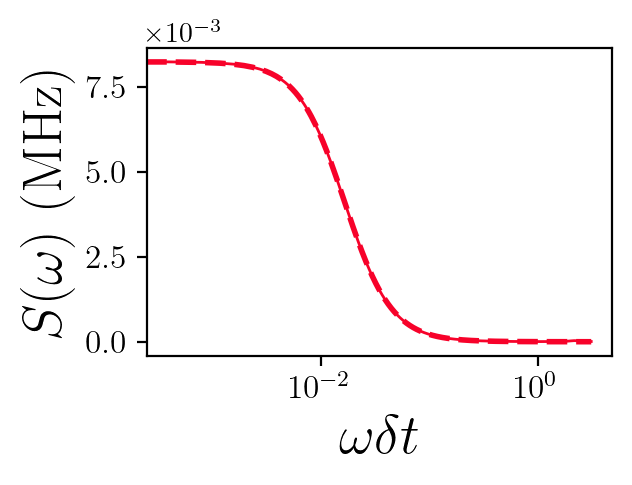

In [126]:
plt.figure(figsize=(3,2), dpi=200)

ww, h_hat = si.freqz(b_hat,a_hat,worN=worN,whole=False)
PSD = np.abs(h_hat)**2
plt.plot(ww, PSD, color=colors_greg[6], lw=1, ls='-')

def OU_fun(w,sigma,gamma):
    return sigma**2*gamma/(w**2+gamma**2)
params, _ = spopt.curve_fit(OU_fun, ww, PSD)
plt.plot(ww, OU_fun(ww,*params), color=colors_greg[6], ls='--', lw=2)

plt.ylabel(r'$S(\omega)$ (MHz)', fontsize=20)
plt.xlabel(r'$\omega \delta t$', fontsize=20)
plt.xscale('log')
# plt.yscale('log')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.tick_params(labelsize=12)
# print(plt.ylim())
plt.show()

In [221]:
def OU_fun(w,sigma,gamma,S0): return sigma**2*gamma/(w**2+gamma**2) + S0

ww, h_hat = si.freqz(b_hat,a_hat,worN=worN,whole=False)
PSD_a2 = np.abs(h_hat)**2

params, _ = spopt.curve_fit(OU_fun, ww, PSD_a2)
PSD_a2_fit = OU_fun(ww,*params)

PSD_wn = np.ones(worN)*0.0032

pk.dump((ww,PSD_a2,PSD_a2_fit,PSD_wn), open('../data/figdata-corr_deph-PSDs.p','wb'))

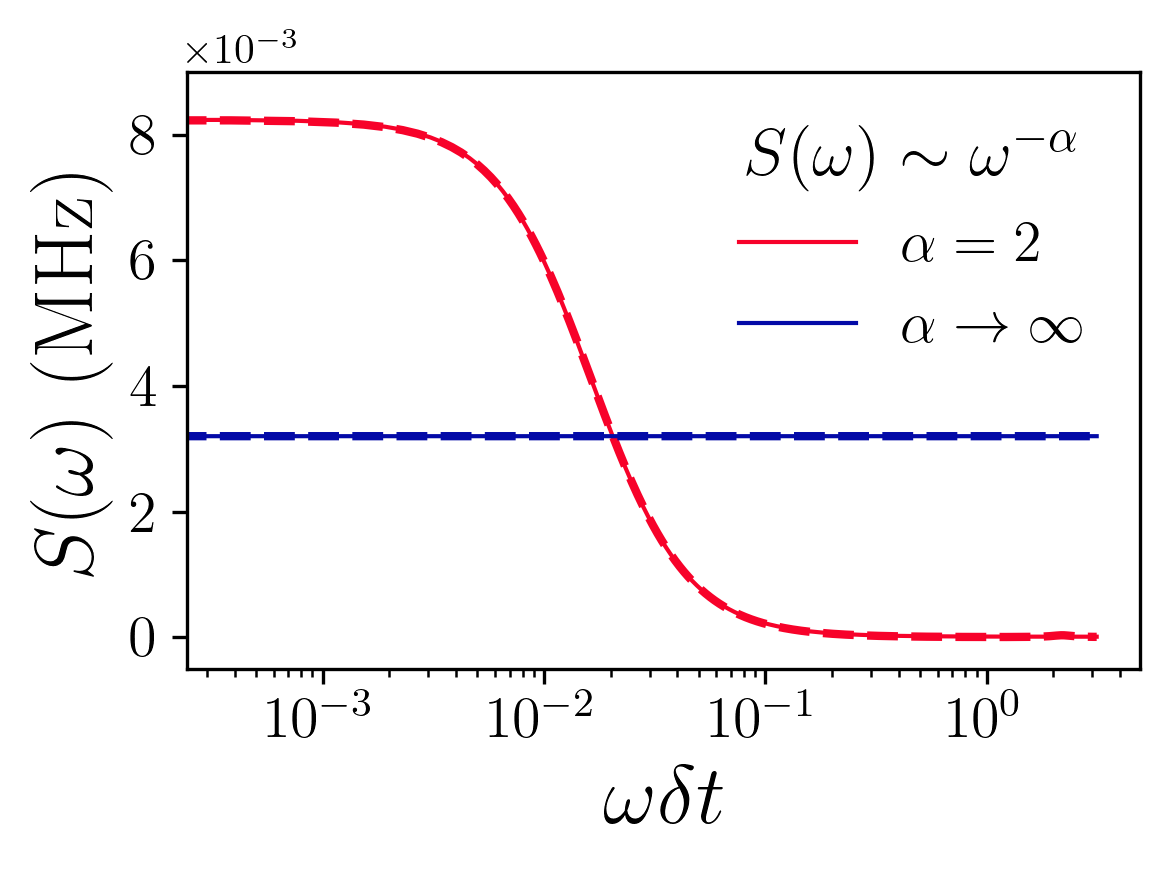

In [220]:
plt.figure(figsize=(4,3), dpi=300)

plt.plot(ww, PSD_a2, color=colors_greg[6], lw=2, ls='--')
plt.plot(ww, PSD_a2_fit, color=colors_greg[6], ls='-', lw=1, label=r'$\alpha=2$')

plt.plot(ww, PSD_wn, color=colors_greg[2], lw=2, ls='--')
plt.plot(ww, PSD_wn, color=colors_greg[2], ls='-', lw=1, label=r'$\alpha\rightarrow\infty$')

plt.ylabel(r'$S(\omega)$ (MHz)', fontsize=20)
plt.xlabel(r'$\omega \delta t$', fontsize=20)
plt.xscale('log')
# plt.yscale('log')
plt.ylim(-.5e-3,9e-3)
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.tick_params(labelsize=14)
plt.legend(frameon=False, fontsize=14, title=r'$S(\omega) \sim \omega^{-\alpha}$',title_fontsize=16)
plt.tight_layout()
plt.savefig('figures/corr_deph_PSD.png')
plt.show()

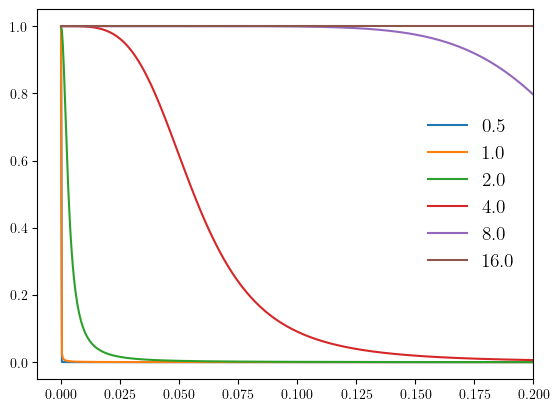

In [192]:
def fun_1f(w,A,alpha,f0): return A/(w**alpha+f0)

for alpha in [0.5,1,2,4,8,16]:
    psd = fun_1f(ww,1,alpha,1e-5)
    plt.plot(ww, psd/np.max(psd), label='%.1f'%alpha)

plt.xlim(-0.01,0.2)
# plt.xscale('log')
plt.legend(frameon=False,fontsize=14)
plt.show()

# Markovian case

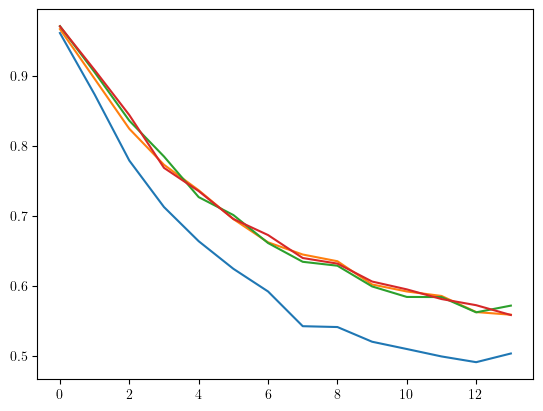

In [248]:
for exp,ps in ps_1f0.items():
    if exp[:2]=='t2':
        plt.plot(ps)
plt.show()

In [222]:
ps_1f0 = pk.load(open('../data/ps_1f0.p','rb'))
x_vals2 = np.linspace(nc.T1_time/len(ps_1f0['t2dd0'])/2,nc.T1_time, len(ps_1f0['t2dd0']))

In [223]:
nc.num_T2 = 14
circs_pulses = {}
list_pulses = [2,4,6]
for n_pulses in list_pulses:
    circs_pulses[n_pulses] = gen_T2DD_circs(n_pulses,flip=False)

In [224]:
FFs_pulses = {pulses:{t:(np.abs(compute_gen_dephasing_Fourier(circ, worN=2*worN+1))**2/(2*worN)/2)[:worN,1,2]
                                for t,circ in enumerate(circs)} for pulses,circs in circs_pulses.items()}

In [225]:
PSD = np.ones(worN)*0.0032

In [226]:
p_k_markov = {}
for pulses,FFs in FFs_pulses.items():
    p_k_markov[pulses] = []
    for t,FF in FFs.items():
        chi = np.sum(FF*PSD)*2
        p_k_markov[pulses] += [(1+(1-2*spam)*np.exp(-chi))/2]

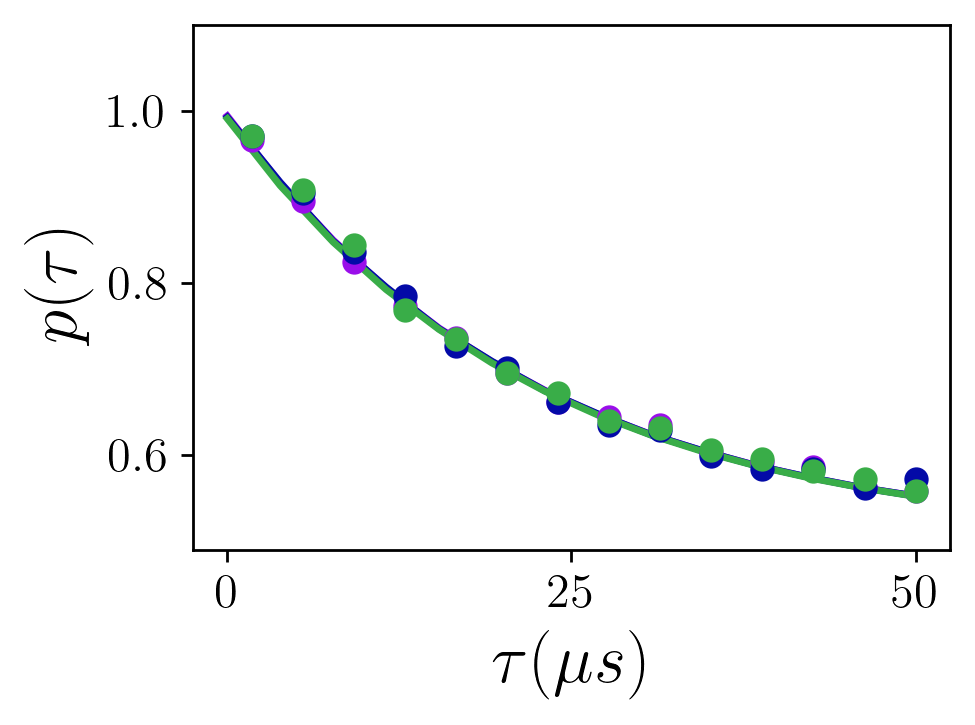

In [227]:
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap_greg', colors_greg, N=len(exp_type))
colors_fine = [cmap(i) for i in range(cmap.N)]

plt.figure(figsize=(4,3), dpi=250)
tt_sim = np.linspace(0,x_vals2[-1],nc.num_T2)
for pulses,ps in p_k_markov.items():
    plt.plot(tt_sim, ps, color=colors_greg[pulses-2], lw=2)
for exp_num, exp in enumerate(exp_type[2:5]):
    plt.plot(x_vals2, ps_1f0[exp], color=colors_greg[2*exp_num], lw=0, marker='o', alpha=1, label=2*(exp_num+1))
    
plt.ylabel(r'$p(\tau)$', fontsize=20)
plt.xlabel(r'$\tau (\mu s)$', fontsize=20)
plt.ylim(0.49,1.1)
plt.xticks([0,25,50], size=14)
plt.yticks([0.6,0.8,1.], size=14)

plt.tight_layout()
plt.show()

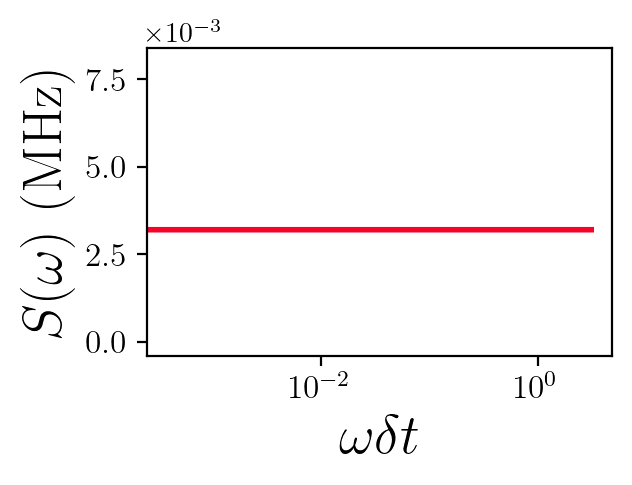

In [234]:
plt.figure(figsize=(3,2), dpi=200)

PSD = np.ones(worN)*0.0032
plt.plot(ww, PSD, color=colors_greg[6], lw=2)

plt.ylabel(r'$S(\omega)$ (MHz)', fontsize=20)
plt.xlabel(r'$\omega \delta t$', fontsize=20)
plt.xscale('log')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.tick_params(labelsize=12)
plt.ylim(-0.0004, 0.0084)
plt.show()

# Together

In [237]:
pk.dump((exp_type,x_vals,x_vals2,p_k,p_k_markov,ps_1f0,ps_dd), open('../data/figdata-corr_deph-DD.p','wb'))

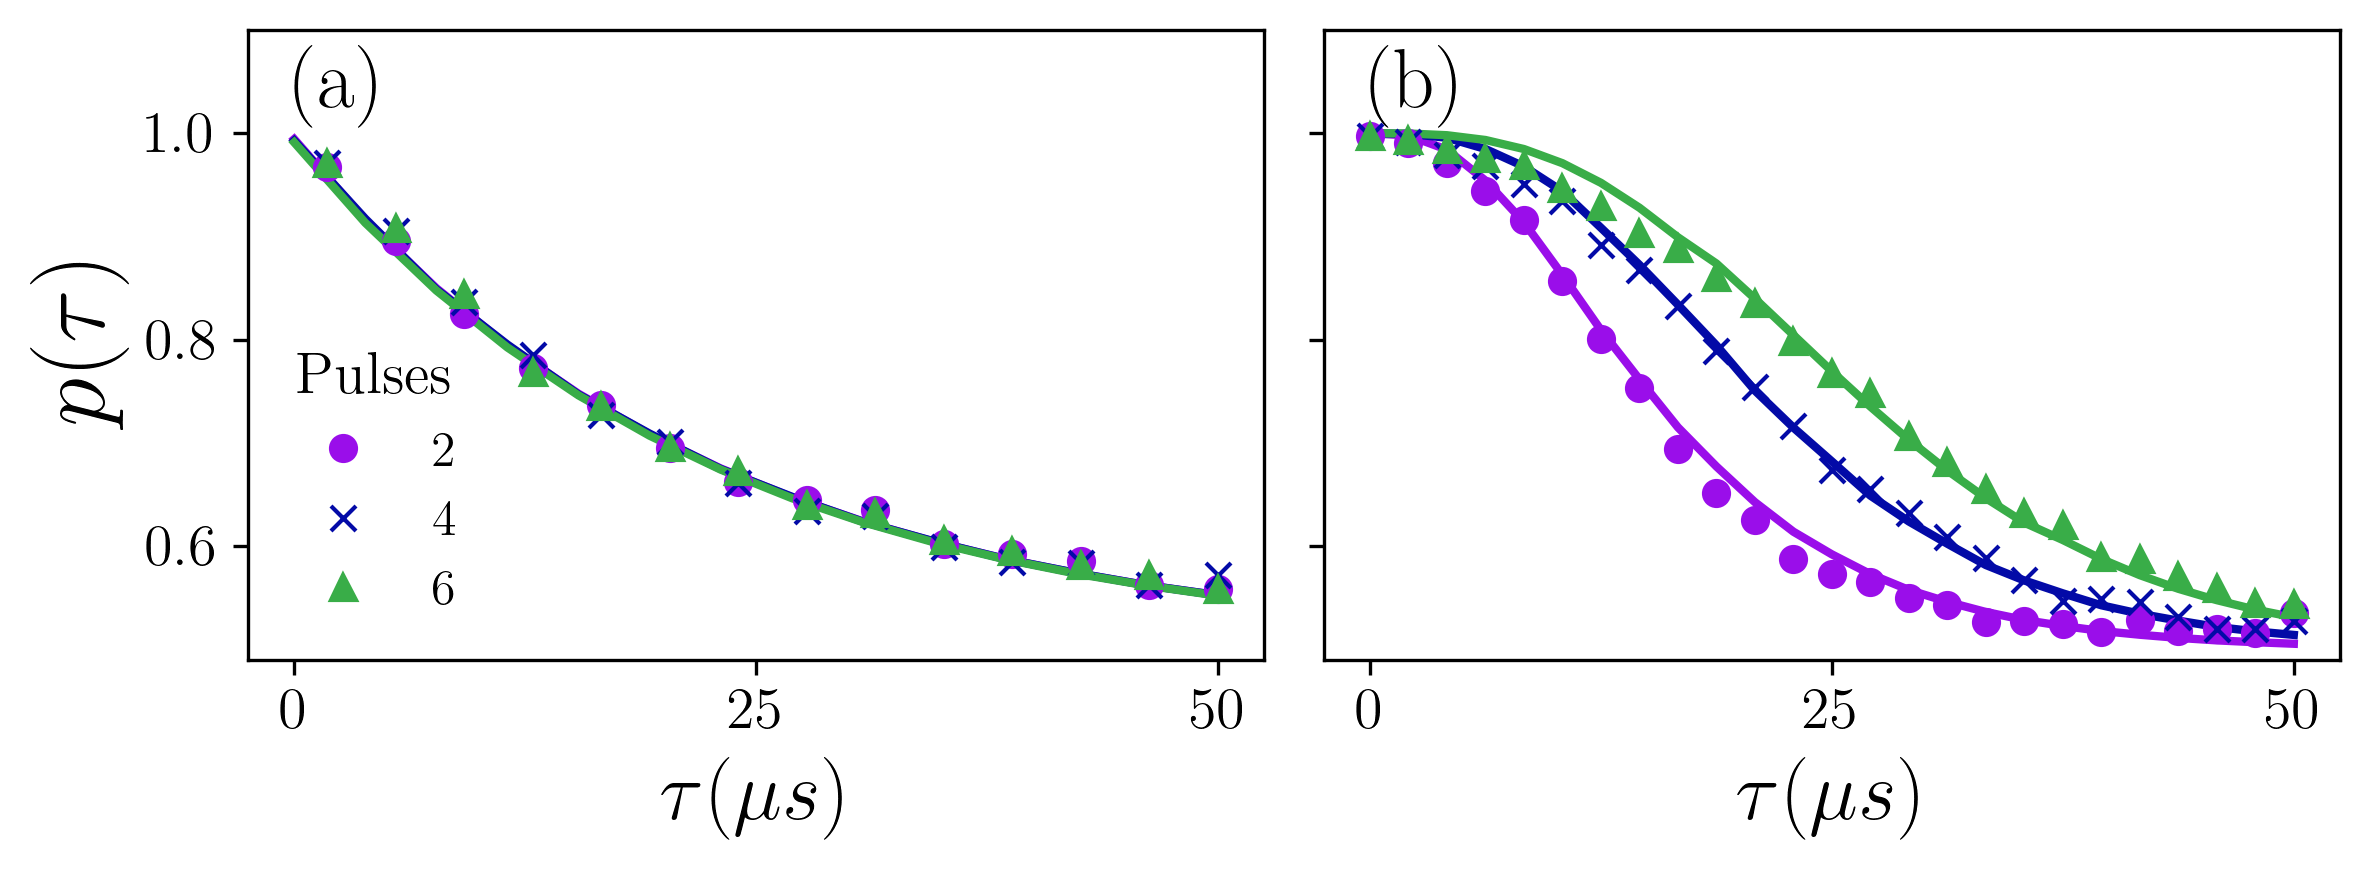

In [236]:
cmap = mpl.colors.LinearSegmentedColormap.from_list('cmap_greg', colors_greg, N=len(exp_type))
colors_fine = [cmap(i) for i in range(cmap.N)]

markers = ['o','x','^']

plt.figure(figsize=(8,3), dpi=300)

plt.subplot(121)
tt_sim = np.linspace(0,50,14)
for pulses,ps in p_k_markov.items():
    plt.plot(tt_sim, ps, color=colors_greg[pulses-2], lw=2)
for exp_num, exp in enumerate(exp_type[2:5]):
    plt.plot(x_vals2, ps_1f0[exp], color=colors_greg[2*exp_num], lw=0, marker=markers[exp_num], alpha=1, label=2*(exp_num+1))

plt.text(0,1.025,'(a)', size=20)
plt.legend(frameon=False, fontsize=12, title='Pulses', title_fontsize=14, ncol=1, loc=3)
plt.ylabel(r'$p(\tau)$', fontsize=24)
plt.xlabel(r'$\tau (\mu s)$', fontsize=20)
plt.ylim(0.49,1.1)
plt.xticks([0,25,50], size=14)
plt.yticks([0.6,0.8,1.], size=14)

plt.subplot(122)
for pulses,ps in p_k.items():
    plt.plot(x_vals[exp], ps, color=colors_greg[pulses-2], lw=2)
for exp_num, exp in enumerate(exp_type[2:5]):
    plt.plot(x_vals[exp], ps_dd[exp], color=colors_greg[2*exp_num], lw=0, marker=markers[exp_num], alpha=1, label=2*(exp_num+1))

plt.text(0,1.025,'(b)', size=20)
plt.xlabel(r'$\tau (\mu s)$', fontsize=20)
plt.ylim(0.49,1.1)
plt.xticks([0,25,50], size=14)
plt.yticks([0.6,0.8,1.],['','',''], size=14)

# plt.axhline(0.5, color='k', ls='--', lw=1)
plt.tight_layout()

plt.show()

See
23-07-25 - 1f noise - hanoi
and
23-06-11 - 1f noise - manila - ibmresearch - paper FIG